# Semi-Supervised Learning with Logical Constraints

This notebook explores when logical constraints are actually useful in neural network training. We will use the classic MNIST digit classification task to illustrate a key insight:

> *Logical constraints are most valuable when you have unlabeled data.*

By the end of this notebook, we will have seen:

1. How to compose the `exactly_one` constraint from `Exists` and `ForAll` quantifiers
2. How to combine supervised and constraint losses in a semi-supervised training loop
3. How the constraint acts as entropy minimization on unlabeled data
4. Why logical constraints are most valuable when labeled data is scarce

It uses similar notation as the [MNIST notebook](MNIST.ipynb).

In supervised learning with softmax outputs, constraints like "exactly one digit should be predicted" are redundant because softmax already enforces a valid probability distribution, and cross-entropy loss already pushes toward confident predictions.

But in semi-supervised learning, where we have both labeled and unlabeled data, logical constraints provide a principled way to leverage the unlabeled examples. The constraint acts as a form of regularization that encourages the model to make confident predictions even without labels.

## Preliminaries

To get started, let us first get the standard preambles out of the way. We need a bunch of imports. (The `torchvision` library is not part of `pysignet`'s dependencies, and will need to be installed separately.)

In [18]:
%pip install torchvision -q -q

Note: you may need to restart the kernel to use updated packages.


In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import pysignet as psn

## Setting up the logic

We will work with the standard MNIST dataset, which seeks to label images with the numbers they contain. To write this in logic, let us consider an image `X` that has a label `Y`. We can define a predicate `Digit` to represent this: `Digit(X, Y)` is the statement that the image `X` has label `Y`.

Let us declare the symbols for the predicate and its arguments.

In [20]:
Digit = psn.Symbol("Digit")
X, Y = psn.Variable("X Y")

### The at-least-one constraint

We can write a rule that says that for any input image `X`, there is some digit `Y` in the range 0 to 9 such that `Digit(X, Y)` holds:

$$\forall \texttt{X}, \exists \texttt{Y} \in \{0, \ldots, 9\}: \texttt{Digit}(X, Y)$$

In [35]:
at_least_one = psn.Exists(Y, range(10), Digit(X, Y))
at_least_one

Exists(Y, [0, 1, 2, 3, 4, ...], Digit(X, Y))

### The at-most-one constraint

We can also write a constraint saying that for any input image `X`, at most one digit holds. For every pair of distinct digits $I$ and $J$, it cannot be the case that both `Digit(X, I)` and `Digit(X, J)` hold simultaneously:

$$\forall \texttt{X}, \forall (I, J) \in \{(i,j) : i < j\}: \neg(\texttt{Digit}(X, I) \wedge \texttt{Digit}(X, J))$$

We enumerate all pairs and use `ForAll` over them.

In [36]:
I, J = psn.Variable("I J")

all_pairs = [(i, j) for i in range(10) for j in range(i+1, 10)]

at_most_one = psn.ForAll([I, J],
                         all_pairs,
                         psn.Not(psn.And(Digit(X, I), Digit(X, J))))

at_most_one

ForAll([I, J], [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), ...], ~(Digit(X, J) & Digit(X, I)))

### The exactly-one constraint

For multi-class classification, we often want to express that exactly one class should be predicted. Mathematically, we can write this as:

$$\exists! y \in \{0, \ldots, 9\}: \text{Digit}(X, y)$$

This "exists unique" quantifier ($\exists!$) decomposes into the at-least-one and the at-most-one parts. In other words, the "exactly one" constraint is the conjunction of the two.

In [37]:
exactly_one = psn.And(at_least_one, at_most_one)

exactly_one

Exists(Y, Digit(X, Y)) & ForAll((I, J), ~(Digit(X, J) & Digit(X, I)))

## Loading the dataset

Next, let us set up the data loading infrastructure.

In [24]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten to 784
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 60000
Test samples: 10000


## The semi-supervised setting

In practice, labeled data is expensive to obtain while unlabeled data is plentiful. To simulate this, we will use only a small fraction of the training labels and treat the rest as unlabeled data. Specifically, we will keep 50 labeled examples (about 5 per digit) and 5000 unlabeled examples.

In [25]:
n_labeled = 50
n_unlabeled = 5000

torch.manual_seed(1)
indices = torch.randperm(len(train_dataset))
labeled_indices = indices[:n_labeled]
unlabeled_indices = indices[n_labeled:n_labeled + n_unlabeled]

labeled_dataset = Subset(train_dataset, labeled_indices)
unlabeled_dataset = Subset(train_dataset, unlabeled_indices)

labeled_loader = DataLoader(labeled_dataset, batch_size=32, shuffle=True)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"Labeled samples: {n_labeled}")
print(f"Unlabeled samples: {n_unlabeled}")

Labeled samples: 50
Unlabeled samples: 5000


## The model

We will use the same simple multi-layer perceptron as in the [MNIST notebook](MNIST.ipynb). There is nothing fancy about this network.

In [26]:
class MNISTClassifier(nn.Module):
    def __init__(self, hidden_size: int = 256):
        super().__init__()
        self.fc1 = nn.Linear(784, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)  # logits

    def predict_probs(self, x: torch.Tensor) -> torch.Tensor:
        return F.softmax(self.forward(x), dim=-1)

## The evaluator

We will track accuracy throughout training using `consistency_report`. Accuracy is equivalent to asking how often the model satisfies the constraint `Digit(X, Y)`, i.e., how often it predicts the correct label.

In [27]:
def evaluate(model: nn.Module, loader: DataLoader) -> float:
    checker = psn.consistency_report(Digit(X, Y), {"Digit": model})
    for x, y in loader:
        checker.eval(X=x, Y=y)
    return checker.global_consistency()

## Baseline: supervised only

First, let us see how well we can do with just the 50 labeled examples and standard cross-entropy loss. This is our baseline.

In [28]:
def train_supervised_only(n_epochs: int = 5, lr: float = 0.001):
    model = MNISTClassifier()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(n_epochs):
        model.train()
        for x, y in labeled_loader:
            optimizer.zero_grad()
            loss = F.cross_entropy(model(x), y)
            loss.backward()
            optimizer.step()

        acc = evaluate(model, test_loader)
        history.append(acc)
        print(f"Epoch {epoch + 1:2d}: accuracy = {acc:.4f}")

    return model, history

In [29]:
torch.manual_seed(1)

model_baseline, history_baseline = train_supervised_only()

Epoch  1: accuracy = 0.2856
Epoch  2: accuracy = 0.3398
Epoch  3: accuracy = 0.4084
Epoch  4: accuracy = 0.4215
Epoch  5: accuracy = 0.4856


With just 50 labels, the model struggles. It has very little supervision to learn from, so test accuracy is limited. Can we do better by also using the unlabeled data?

## Semi-supervised training with the constraint

Here is the key idea. Even though we do not have labels for the unlabeled examples, we know something about what the model's predictions should look like: for each image, exactly one digit should be predicted. This is the `exactly_one` constraint we defined earlier.

We can compile this constraint into a loss function and apply it to the unlabeled data. The training loop combines two losses:

1. **Cross-entropy** on labeled data (standard supervised loss)
2. **Constraint loss** on unlabeled data (encourages confident, one-hot predictions)

There are two things to keep in mind when combining these losses. First, we need the two loss terms to be on the same scale. By default, `F.cross_entropy` averages across the batch, so we do the same for the constraint loss by using `quantify='none', reduction='mean'`. Second, it helps to warm up with just supervised training for a few epochs. This lets the model learn basic features before the constraint pushes it to be confident.

These differences from the baseline are annotated in the code below.

In [30]:
def train_semi_supervised(n_epochs: int = 4, warmup_epochs: int = 1,
                          lr: float = 0.001, constraint_weight: float = 0.01):
    model = MNISTClassifier()

    # 1. Compile the exactly-one constraint into a loss generator
    predicates = {"Digit": model}
    constraint = psn.logic_to_loss(exactly_one, predicates)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(warmup_epochs):
        model.train()
        for x_labeled, y_labeled in labeled_loader:
            optimizer.zero_grad()
            F.cross_entropy(model(x_labeled), y_labeled).backward()
            optimizer.step()
        acc = evaluate(model, test_loader)
        history.append(acc)
        print(f"Epoch {epoch + 1:2d} (warmup): accuracy = {acc:.4f}")

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(n_epochs):
        model.train()
        unlabeled_iter = iter(unlabeled_loader)

        for x_labeled, y_labeled in labeled_loader:
            optimizer.zero_grad()

            ce_loss = F.cross_entropy(model(x_labeled), y_labeled)

            try:
                x_unlabeled, _ = next(unlabeled_iter)
            except StopIteration:
                unlabeled_iter = iter(unlabeled_loader)
                x_unlabeled, _ = next(unlabeled_iter)

            # 2. Compute per-example constraint loss on unlabeled data,
            #    averaged to match the cross-entropy scale
            logic_loss = constraint.loss(
                X=x_unlabeled, quantify='none', reduction="mean",
            )

            # 3. Combine supervised and constraint losses
            total_loss = ce_loss + constraint_weight * logic_loss

            total_loss.backward()
            optimizer.step()

        acc = evaluate(model, test_loader)
        history.append(acc)
        print(f"Epoch {warmup_epochs + epoch + 1:2d}: accuracy = {acc:.4f}")

    return model, history

*A note about experimental setup:* The semi-supervised loop runs one warmup epoch followed by four constraint-aware epochs, for a total of five, matching the supervised baseline. Calling `torch.manual_seed(1)` before each training function ensures both models start from identical weights and see the labeled data in the same order. This is why the two learning curves begin at the same point: epoch 1 (warmup) is identical to epoch 1 of the supervised run.

In [31]:
torch.manual_seed(1)

model_semi, history_semi = train_semi_supervised()

Epoch  1 (warmup): accuracy = 0.2856
Epoch  2: accuracy = 0.3751
Epoch  3: accuracy = 0.4393
Epoch  4: accuracy = 0.4845
Epoch  5: accuracy = 0.5506


## Comparing the two approaches

Let us plot the learning curves for both models and look at the final numbers.

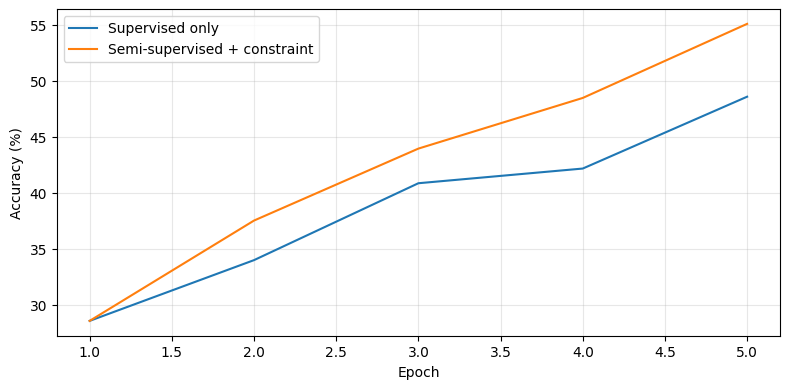

Supervised only:              0.4856
Semi-supervised + constraint: 0.5506
Improvement: +6.5 percentage points


In [32]:
import matplotlib.pyplot as plt

epochs = range(1, len(history_baseline) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, [a * 100 for a in history_baseline], label='Supervised only')
ax.plot(epochs, [a * 100 for a in history_semi], label='Semi-supervised + constraint')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Supervised only:              {history_baseline[-1]:.4f}")
print(f"Semi-supervised + constraint: {history_semi[-1]:.4f}")
print(f"Improvement: {(history_semi[-1] - history_baseline[-1]) * 100:+.1f} percentage points")

The semi-supervised model converges faster at every epoch after the warmup. After five epochs, it reaches around 55% accuracy compared to 49% for the baseline. This represents a gain of roughly 6 percentage points from the same number of labeled examples, by exploiting the structure of the constraint on unlabeled data.

## The constraint as entropy minimization

The accuracy improvement comes from what the constraint is doing to the model's predictions on unlabeled data. To satisfy `exactly_one`, the model must concentrate its probability mass on a single class for every input, labeled or not. This is a form of entropy minimization: it pushes the model toward confident predictions even when no label is available.

Let us verify this by measuring prediction entropy on the test set for both models.

In [33]:
def compute_entropy(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    entropies = []
    with torch.no_grad():
        for x, _ in loader:
            probs = model.predict_probs(x)
            entropy = -torch.sum(probs * torch.log(probs + 1e-10), dim=-1)
            entropies.append(entropy)
    return torch.cat(entropies).mean().item()

entropy_baseline = compute_entropy(model_baseline, test_loader)
entropy_semi = compute_entropy(model_semi, test_loader)

print("Prediction entropy (lower = more confident):")
print(f"  Supervised only:         {entropy_baseline:.4f}")
print(f"  Semi-supervised + logic: {entropy_semi:.4f}")
print(f"  Maximum possible:        {torch.log(torch.tensor(10.0)):.4f}")

Prediction entropy (lower = more confident):
  Supervised only:         1.9295
  Semi-supervised + logic: 1.8686
  Maximum possible:        2.3026


The constraint has already begun to reduce prediction entropy after five epochs, though the effect is modest this early in training. With more training the entropy reduction grows, but so does the supervised signal. Eventually the labeled data is seen enough times that it dominates, and the two models converge to similar performance. The constraint is most valuable precisely in this early phase, when labels are scarce and the model has not yet seen the data enough times to override it.

## Evaluating consistency

As in the MNIST notebook, we can evaluate how well the model satisfies the constraint. Since `exactly_one` is a logical formula, we can use `pysignet`'s consistency report to measure satisfaction on the test set.

In [34]:
evaluator = psn.consistency_report(
    exactly_one, predicates={"Digit": model_semi}
)

for x, _ in test_loader:
    evaluator.eval(X=x)

evaluator

ConsistencyReport(10000/10000 satisfied)
  global_violation (rho): 0.0000
  global_consistency:     1.0000

The key takeaway from this notebook is that logical constraints are most valuable when labeled data is scarce and training time is limited. The `exactly_one` constraint provides free signal from unlabeled data, allowing the model to learn faster than supervised training alone.

This advantage is most pronounced early in training. With enough epochs, the data eventually overrules the constraint: the model sees the labeled examples repeatedly and the supervised signal dominates regardless. Logical constraints therefore act as an accelerant, most valuable when labels are scarce or hard to collect.

A natural next step is to see how `pysignet` handles relational constraints, such as enforcing symmetry in a learned similarity function. See the [Symmetry Constraints notebook](Symmetry%20Constraints.ipynb).